# The Billion-Dollar Illusion: Healthy User Bias Simulation

**Article:** [The Billion-Dollar Illusion: When Data Lies About Your Health](https://beyondcorrelation1.substack.com/p/the-billion-dollar-illusion-when)

This notebook is the **interactive companion** to the article. Read the post for the full story — 87,000 nurses, a 40% Vitamin E effect that vanished in RCTs, and the **Healthy User Bias** behind the illusion.

Here we simulate the bias in Python: the vitamin has **zero causal effect**, but healthier people are more likely to take it. Run the cell below to reproduce **Figure 1** from the article and the observed gap in the console output.

### The Experiment
1. Generate **10,000 people**.
2. **Ground truth:** health depends on lifestyle only — the vitamin is a placebo:

   $$\text{Health} = 30 + (50 \times \text{Lifestyle}) + (0 \times \text{Vitamin})$$

3. **The bias:** people with higher health consciousness are more likely to take the vitamin.

**Top plot (Oracle Mode):** un-collapsed data — parallel trend lines show the vitamin has no effect.

**Bottom plot (Observer Mode):** collapsed data — ignoring lifestyle creates an illusionary gap between groups.

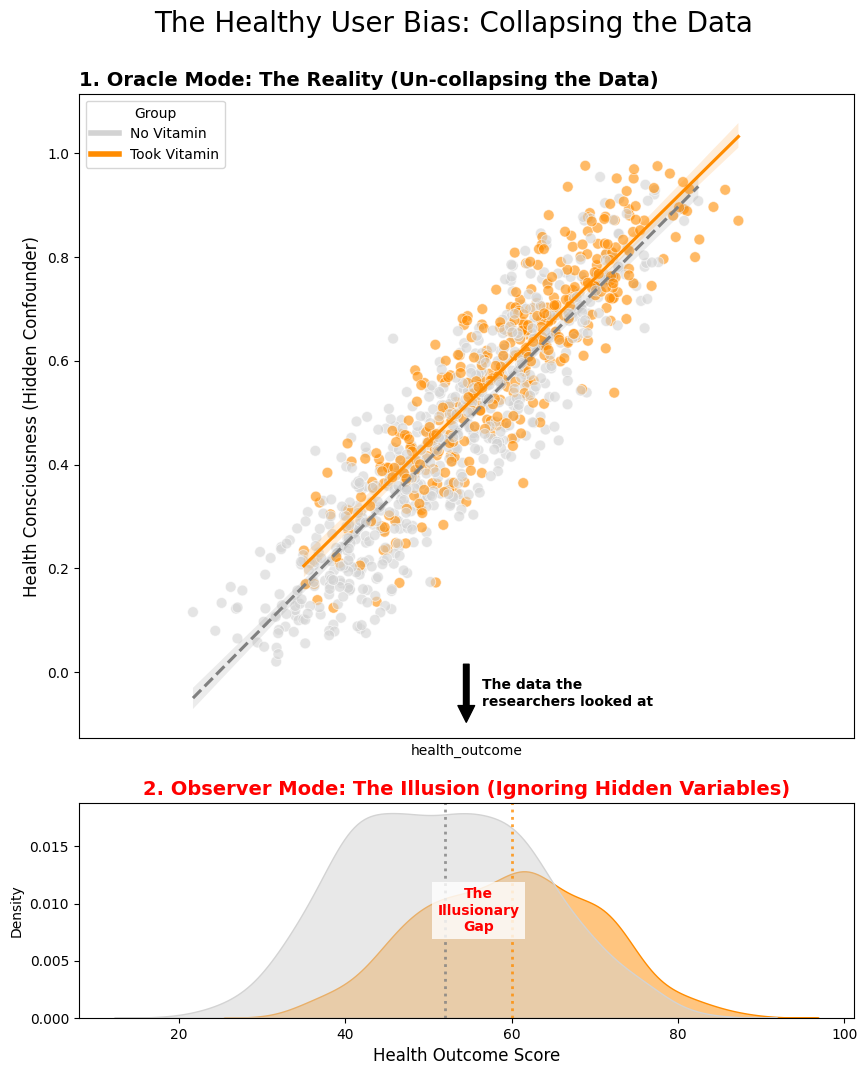

------------------------------
THE DATA PROOF
------------------------------
Average Health (Vitamin Users): 60.03
Average Health (Non-Users):     52.00
Observed GAP (The Bias):        8.03
------------------------------
REALITY CHECK:
Did we program a vitamin effect? NO (Coefficient is 0)
Why is there a gap? Because healthy people CHOSE the vitamin.
------------------------------


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Generate Data ---
np.random.seed(42)
n = 10000

health_consciousness = np.random.beta(2, 2, n)
prob_taking_vitamin = health_consciousness * 0.8
take_vitamin = np.random.binomial(1, prob_taking_vitamin)
health_outcome = 30 + (50 * health_consciousness) + np.random.normal(0, 5, n)

df = pd.DataFrame({
    'take_vitamin': take_vitamin,
    'health_outcome': health_outcome,
    'health_consciousness': health_consciousness
})

plot_df = df.sample(1000, random_state=42)

# --- 2. Build the Vertical Joint Plot ---
fig = plt.figure(figsize=(10, 12))
gs = fig.add_gridspec(2, 1, height_ratios=(3, 1), hspace=0.15)

ax_scatter = fig.add_subplot(gs[0, 0])
ax_hist = fig.add_subplot(gs[1, 0], sharex=ax_scatter)

# --- TOP PLOT: The Reality (Scatter) ---
sns.scatterplot(
    data=plot_df,
    x='health_outcome',
    y='health_consciousness',
    hue='take_vitamin',
    palette={0: 'lightgrey', 1: 'darkorange'},
    alpha=0.6,
    s=60,
    ax=ax_scatter,
    legend=False
)

sns.regplot(data=plot_df[plot_df['take_vitamin'] == 0], x='health_outcome', y='health_consciousness',
            scatter=False, color='grey', ax=ax_scatter, line_kws={'linestyle': '--'})
sns.regplot(data=plot_df[plot_df['take_vitamin'] == 1], x='health_outcome', y='health_consciousness',
            scatter=False, color='darkorange', ax=ax_scatter)

ax_scatter.set_title("1. Oracle Mode: The Reality (Un-collapsing the Data)", fontsize=14, fontweight='bold', loc='left')
ax_scatter.set_ylabel("Health Consciousness (Hidden Confounder)", fontsize=12)
ax_scatter.tick_params(axis='x', bottom=False, labelbottom=False)

ax_scatter.annotate('', xy=(0.5, 0.02), xycoords='axes fraction',
                    xytext=(0.5, 0.12), textcoords='axes fraction',
                    arrowprops=dict(facecolor='black', shrink=0.05))
ax_scatter.text(0.52, 0.07, "The data the\nresearchers looked at", transform=ax_scatter.transAxes,
                fontsize=10, ha='left', va='center', fontweight='bold')

from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='lightgrey', lw=4),
                Line2D([0], [0], color='darkorange', lw=4)]
ax_scatter.legend(custom_lines, ['No Vitamin', 'Took Vitamin'], loc='upper left', title="Group")

# --- BOTTOM PLOT: The Illusion (Density) ---
sns.kdeplot(
    data=plot_df,
    x='health_outcome',
    hue='take_vitamin',
    palette={0: 'lightgrey', 1: 'darkorange'},
    fill=True,
    alpha=0.5,
    ax=ax_hist,
    legend=False
)

ax_hist.set_title("2. Observer Mode: The Illusion (Ignoring Hidden Variables)", fontsize=14, fontweight='bold', color='red')
ax_hist.set_xlabel("Health Outcome Score", fontsize=12)
ax_hist.set_ylabel("Density")

mean_vit = df[df['take_vitamin'] == 1]['health_outcome'].mean()
mean_no = df[df['take_vitamin'] == 0]['health_outcome'].mean()

ax_hist.axvline(mean_vit, color='darkorange', linestyle=':', alpha=0.8, lw=2)
ax_hist.axvline(mean_no, color='grey', linestyle=':', alpha=0.8, lw=2)
ax_hist.text((mean_vit + mean_no) / 2, ax_hist.get_ylim()[1] * 0.5, "The\nIllusionary\nGap",
             ha='center', va='center', color='red', fontweight='bold', fontsize=10,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.suptitle("The Healthy User Bias: Collapsing the Data", fontsize=20, y=0.95)
plt.show()

# --- 3. Proof: Checking the Averages (The Bias) ---
print("-" * 30)
print("THE DATA PROOF")
print("-" * 30)
print(f"Average Health (Vitamin Users): {mean_vit:.2f}")
print(f"Average Health (Non-Users):     {mean_no:.2f}")
print(f"Observed GAP (The Bias):        {mean_vit - mean_no:.2f}")
print("-" * 30)
print("REALITY CHECK:")
print("Did we program a vitamin effect? NO (Coefficient is 0)")
print("Why is there a gap? Because healthy people CHOSE the vitamin.")
print("-" * 30)

## Takeaway

The vitamin had zero effect — the gap comes entirely from who chose to take it. In real health data, that selection bias can look like a billion-dollar miracle.